# Cross-Test: Last7Days Embeddings → Jump-Point 5 Models

**Goal**: Test whether the jump-point trained classifiers generalise to the raw last-7-days embeddings.  
**Input A**: Raw last-7-days Time2Vec embeddings (32 / 64 / 128 dim)  
**Input B**: Jump-point tuned classifiers + scalers from `5models/7daysjumppoint_withtime/`  

**Two evaluations per dim per model:**
1. **All splits** (train + val + test combined) → overall generalisation
2. **Test split only** → fair held-out evaluation
```
last7days emb_train/val/test
  → apply jumppoint scaler
  → predict with each tuned jumppoint model
  → report acc / AUC / F1  (all splits combined  +  test only)
  → save results CSV + confusion matrices
```

---
## Step 1 — Install & Import

In [7]:
!pip install -q xgboost scikit-learn

In [8]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report
)

print('All imports OK')

All imports OK


---
## Step 2 — Mount Drive & Set Paths

In [9]:
from google.colab import drive
drive.mount('/content/drive')

BASE_AI     = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI"

# Last-7-days raw embeddings (source to test FROM)
LAST7_EMB_ROOT = os.path.join(BASE_AI, "Best_Model")

# Jump-point trained classifiers (models to test ON)
JP_MODELS_ROOT = os.path.join(BASE_AI, "5models", "7daysjumppoint_withtime")

# Where to save cross-test results
OUT_ROOT = os.path.join(JP_MODELS_ROOT, "crosstest_last7days_on_jpmodels")
os.makedirs(OUT_ROOT, exist_ok=True)

EMBED_DIMS = [32, 64, 128]

# Classifier save names — must match what was saved in the 5models notebook
CLF_NAMES = {
    'logistic_regression': 'LR',
    'svm':                 'SVM',
    'decision_tree':       'DT',
    'random_forest':       'RF',
    'xgboost':             'XGB',
}

print(f'Last7days embeddings root : {LAST7_EMB_ROOT}')
print(f'Jump-point models root    : {JP_MODELS_ROOT}')
print(f'Output root               : {OUT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Last7days embeddings root : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model
Jump-point models root    : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/5models/7daysjumppoint_withtime
Output root               : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/5models/7daysjumppoint_withtime/crosstest_last7days_on_jpmodels


---
## Step 3 — Pre-flight Check

In [10]:
print('Checking last-7-days embedding files...')
for dim in EMBED_DIMS:
    folder = os.path.join(LAST7_EMB_ROOT,
                 f'daily_embedding_classifier_last7days_{dim}dim_withtime')
    for split in ['emb_train', 'emb_val', 'emb_test']:
        path   = os.path.join(folder, f'{split}.parquet')
        status = '✅' if os.path.exists(path) else '❌ MISSING'
        print(f'  {status}  dim={dim}  {split}')

print('\nChecking jump-point model files...')
for dim in EMBED_DIMS:
    DIM_DIR = os.path.join(JP_MODELS_ROOT, f'{dim}dim')
    scaler_path = os.path.join(DIM_DIR, 'scaler.pkl')
    status = '✅' if os.path.exists(scaler_path) else '❌ MISSING'
    print(f'  {status}  dim={dim}  scaler.pkl')
    for clf_key, save_name in CLF_NAMES.items():
        path   = os.path.join(DIM_DIR, f'{save_name}_best.pkl')
        status = '✅' if os.path.exists(path) else '❌ MISSING'
        print(f'  {status}  dim={dim}  {save_name}_best.pkl')

Checking last-7-days embedding files...
  ✅  dim=32  emb_train
  ✅  dim=32  emb_val
  ✅  dim=32  emb_test
  ✅  dim=64  emb_train
  ✅  dim=64  emb_val
  ✅  dim=64  emb_test
  ✅  dim=128  emb_train
  ✅  dim=128  emb_val
  ✅  dim=128  emb_test

Checking jump-point model files...
  ✅  dim=32  scaler.pkl
  ✅  dim=32  LR_best.pkl
  ✅  dim=32  SVM_best.pkl
  ✅  dim=32  DT_best.pkl
  ✅  dim=32  RF_best.pkl
  ✅  dim=32  XGB_best.pkl
  ✅  dim=64  scaler.pkl
  ✅  dim=64  LR_best.pkl
  ✅  dim=64  SVM_best.pkl
  ✅  dim=64  DT_best.pkl
  ✅  dim=64  RF_best.pkl
  ✅  dim=64  XGB_best.pkl
  ✅  dim=128  scaler.pkl
  ✅  dim=128  LR_best.pkl
  ✅  dim=128  SVM_best.pkl
  ✅  dim=128  DT_best.pkl
  ✅  dim=128  RF_best.pkl
  ✅  dim=128  XGB_best.pkl


---
## Step 4 — Helper: Evaluate & Plot

In [11]:
def compute_metrics(estimator, X, y):
    pred  = estimator.predict(X)
    proba = estimator.predict_proba(X)[:, 1]
    acc   = accuracy_score(y, pred)
    try:   auc = roc_auc_score(y, proba)
    except: auc = float('nan')
    f1    = f1_score(y, pred, zero_division=0)
    return acc, auc, f1, pred


def plot_confusion(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=14)
    ax.set_title(title, fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


print('Helper functions defined.')

Helper functions defined.


---
## Step 5 — Cross-Test: Last7Days Embeddings → Jump-Point Models

For each dim:
- Load last-7-days embeddings (train / val / test)
- Apply the jump-point scaler
- Run each tuned jump-point classifier
- Report metrics for:
  1. **All splits combined** (train + val + test)
  2. **Test split only**


██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 32
██████████████████████████████████████████████████████████████████████
  Aggregated per patient: train=(48, 34)  val=(15, 34)  test=(22, 34)

  [LR]
    ALL  splits : acc=0.5176  auc=0.4586  f1=0.3051


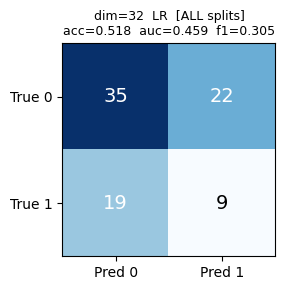

    TEST only   : acc=0.6818  auc=0.7412  f1=0.3636

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.81      0.76      0.79        17
     label 1       0.33      0.40      0.36         5

    accuracy                           0.68        22
   macro avg       0.57      0.58      0.58        22
weighted avg       0.70      0.68      0.69        22



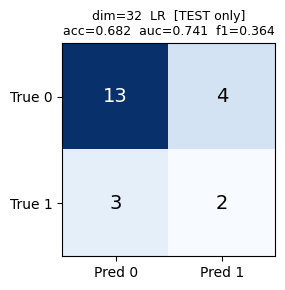


  [SVM]
    ALL  splits : acc=0.5176  auc=0.4693  f1=0.3279


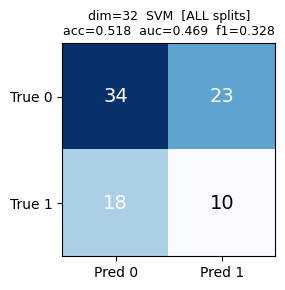

    TEST only   : acc=0.6818  auc=0.7529  f1=0.4615

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.86      0.71      0.77        17
     label 1       0.38      0.60      0.46         5

    accuracy                           0.68        22
   macro avg       0.62      0.65      0.62        22
weighted avg       0.75      0.68      0.70        22



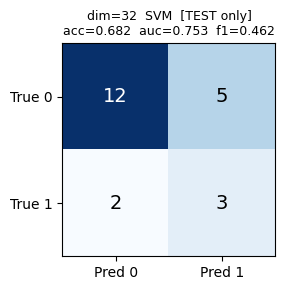


  [DT]
    ALL  splits : acc=0.4353  auc=0.5426  f1=0.5000


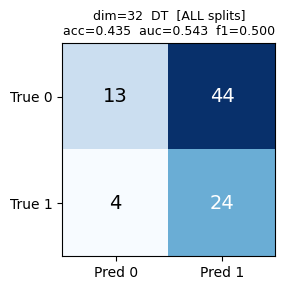

    TEST only   : acc=0.2727  auc=0.3882  f1=0.2727

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.60      0.18      0.27        17
     label 1       0.18      0.60      0.27         5

    accuracy                           0.27        22
   macro avg       0.39      0.39      0.27        22
weighted avg       0.50      0.27      0.27        22



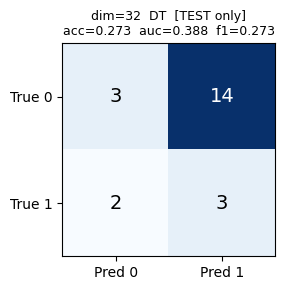


  [RF]
    ALL  splits : acc=0.4353  auc=0.5896  f1=0.4146


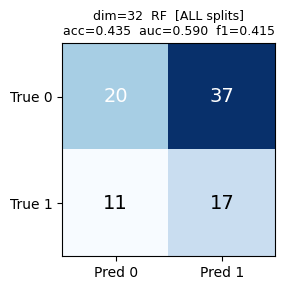

    TEST only   : acc=0.5909  auc=0.8000  f1=0.4706

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.90      0.53      0.67        17
     label 1       0.33      0.80      0.47         5

    accuracy                           0.59        22
   macro avg       0.62      0.66      0.57        22
weighted avg       0.77      0.59      0.62        22



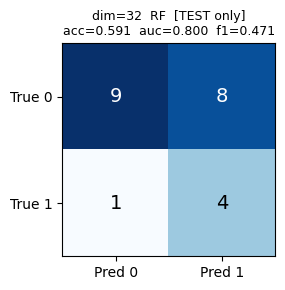


  [XGB]
    ALL  splits : acc=0.3882  auc=0.5423  f1=0.4091


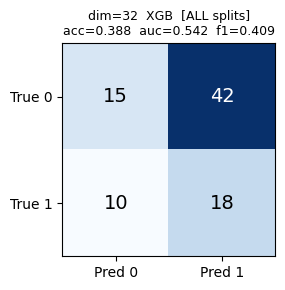

    TEST only   : acc=0.5455  auc=0.7412  f1=0.4444

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.89      0.47      0.62        17
     label 1       0.31      0.80      0.44         5

    accuracy                           0.55        22
   macro avg       0.60      0.64      0.53        22
weighted avg       0.76      0.55      0.58        22



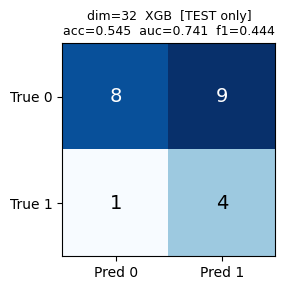


██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 64
██████████████████████████████████████████████████████████████████████
  Aggregated per patient: train=(48, 66)  val=(15, 66)  test=(22, 66)

  [LR]
    ALL  splits : acc=0.3294  auc=0.5000  f1=0.4956


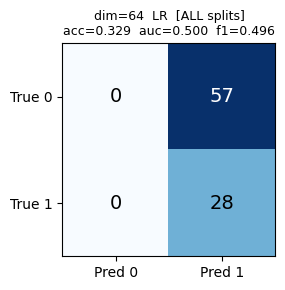

    TEST only   : acc=0.2273  auc=0.5000  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



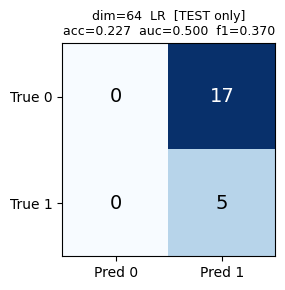


  [SVM]
    ALL  splits : acc=0.3294  auc=0.4793  f1=0.4956


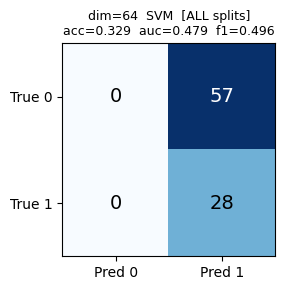

    TEST only   : acc=0.2273  auc=0.7529  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



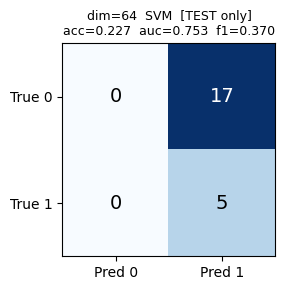


  [DT]
    ALL  splits : acc=0.6706  auc=0.5000  f1=0.0000


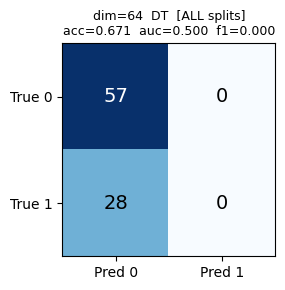

    TEST only   : acc=0.7727  auc=0.5000  f1=0.0000

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.77      1.00      0.87        17
     label 1       0.00      0.00      0.00         5

    accuracy                           0.77        22
   macro avg       0.39      0.50      0.44        22
weighted avg       0.60      0.77      0.67        22



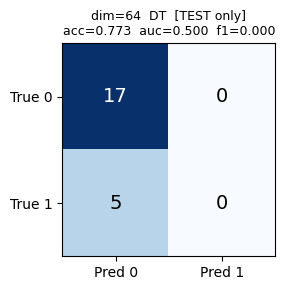


  [RF]
    ALL  splits : acc=0.3294  auc=0.5000  f1=0.4956


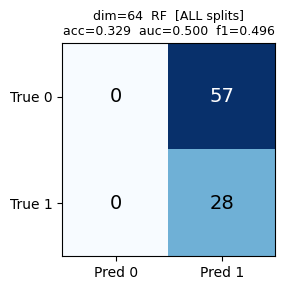

    TEST only   : acc=0.2273  auc=0.5000  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



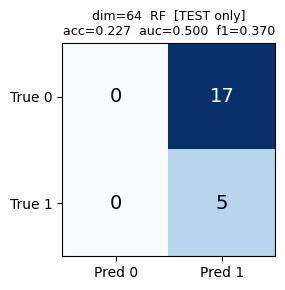


  [XGB]
    ALL  splits : acc=0.3294  auc=0.5000  f1=0.4956


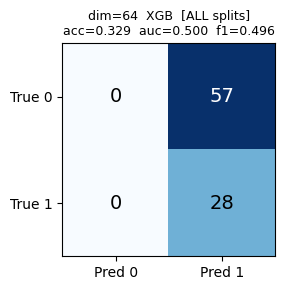

    TEST only   : acc=0.2273  auc=0.5000  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



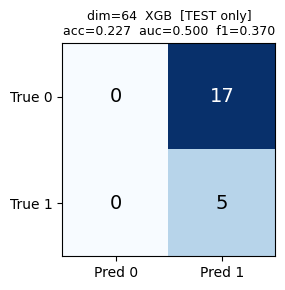


██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 128
██████████████████████████████████████████████████████████████████████
  Aggregated per patient: train=(48, 130)  val=(15, 130)  test=(22, 130)

  [LR]
    ALL  splits : acc=0.3294  auc=0.3853  f1=0.4956


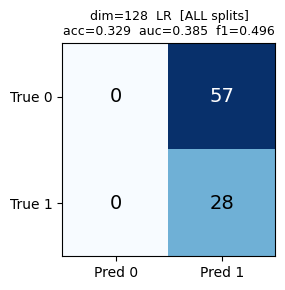

    TEST only   : acc=0.2273  auc=0.6118  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



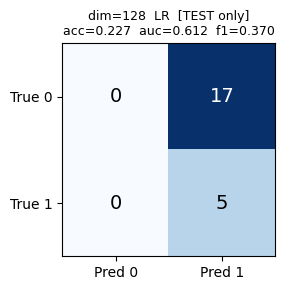


  [SVM]
    ALL  splits : acc=0.3294  auc=0.5670  f1=0.4956


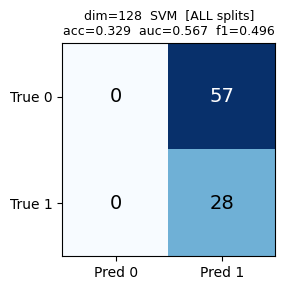

    TEST only   : acc=0.2273  auc=0.6941  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



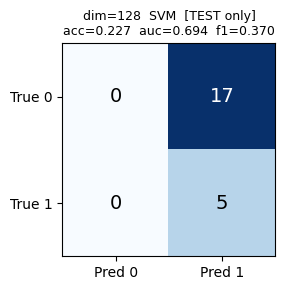


  [DT]
    ALL  splits : acc=0.6706  auc=0.5000  f1=0.0000


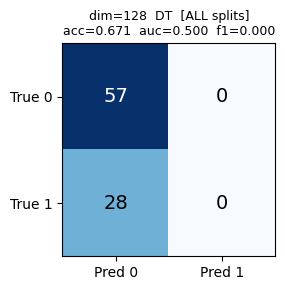

    TEST only   : acc=0.7727  auc=0.5000  f1=0.0000

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.77      1.00      0.87        17
     label 1       0.00      0.00      0.00         5

    accuracy                           0.77        22
   macro avg       0.39      0.50      0.44        22
weighted avg       0.60      0.77      0.67        22



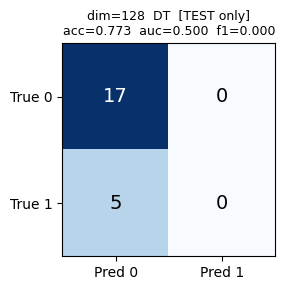


  [RF]
    ALL  splits : acc=0.3294  auc=0.5232  f1=0.4956


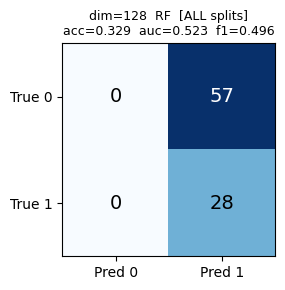

    TEST only   : acc=0.2273  auc=0.4471  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



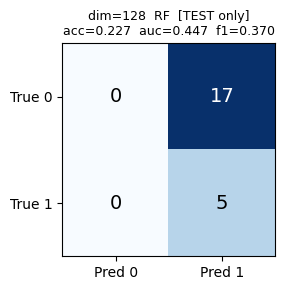


  [XGB]
    ALL  splits : acc=0.3294  auc=0.3963  f1=0.4956


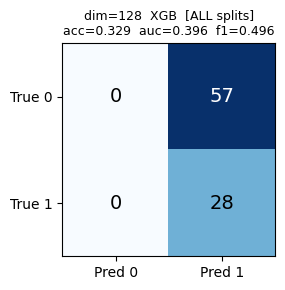

    TEST only   : acc=0.2273  auc=0.4118  f1=0.3704

    Classification report (test):
              precision    recall  f1-score   support

     label 0       0.00      0.00      0.00        17
     label 1       0.23      1.00      0.37         5

    accuracy                           0.23        22
   macro avg       0.11      0.50      0.19        22
weighted avg       0.05      0.23      0.08        22



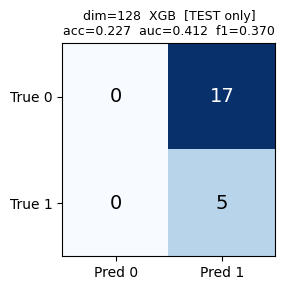


✅ Cross-test results saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/5models/7daysjumppoint_withtime/crosstest_last7days_on_jpmodels/crosstest_results.csv


In [12]:
all_records = []

for EMBED_DIM in EMBED_DIMS:
    print('\n' + '█'*70)
    print(f'  EMBED_DIM = {EMBED_DIM}')
    print('█'*70)

    # ── Load last-7-days embeddings ───────────────────────────────────────────
    L7_FOLDER = os.path.join(
        LAST7_EMB_ROOT,
        f'daily_embedding_classifier_last7days_{EMBED_DIM}dim_withtime'
    )
    emb_train = pd.read_parquet(os.path.join(L7_FOLDER, 'emb_train.parquet'))
    emb_val   = pd.read_parquet(os.path.join(L7_FOLDER, 'emb_val.parquet'))
    emb_test  = pd.read_parquet(os.path.join(L7_FOLDER, 'emb_test.parquet'))

    # last-7-days embeddings have (patient_id, unified_day, label, emb_0..emb_N)
    # we aggregate per patient by averaging across days
    EMB_COLS = [c for c in emb_train.columns if c.startswith('emb_')]

    def agg_by_patient(df):
        """Average embedding across unified_days → 1 row per patient."""
        grp = df.groupby('patient_id')
        embs = grp[EMB_COLS].mean()
        labels = grp['label'].first()
        return embs.join(labels).reset_index()

    # Check if unified_day column exists (last7days has it, jumppoint doesn't)
    if 'unified_day' in emb_train.columns:
        pt_train = agg_by_patient(emb_train)
        pt_val   = agg_by_patient(emb_val)
        pt_test  = agg_by_patient(emb_test)
        print(f'  Aggregated per patient: '
              f'train={pt_train.shape}  val={pt_val.shape}  test={pt_test.shape}')
    else:
        # Already 1 row per patient
        pt_train = emb_train
        pt_val   = emb_val
        pt_test  = emb_test
        print(f'  Loaded: train={pt_train.shape}  val={pt_val.shape}  test={pt_test.shape}')

    X_tr = pt_train[EMB_COLS].values;  y_tr = pt_train['label'].values
    X_va = pt_val  [EMB_COLS].values;  y_va = pt_val  ['label'].values
    X_te = pt_test [EMB_COLS].values;  y_te = pt_test ['label'].values

    # Combined all splits
    X_all = np.vstack([X_tr, X_va, X_te])
    y_all = np.concatenate([y_tr, y_va, y_te])

    # ── Load jump-point scaler & apply ───────────────────────────────────────
    DIM_DIR     = os.path.join(JP_MODELS_ROOT, f'{EMBED_DIM}dim')
    scaler      = joblib.load(os.path.join(DIM_DIR, 'scaler.pkl'))

    X_tr_sc  = scaler.transform(X_tr)
    X_va_sc  = scaler.transform(X_va)
    X_te_sc  = scaler.transform(X_te)
    X_all_sc = scaler.transform(X_all)

    # ── Output dir for this dim ───────────────────────────────────────────────
    DIM_OUT = os.path.join(OUT_ROOT, f'{EMBED_DIM}dim')
    os.makedirs(DIM_OUT, exist_ok=True)

    # ── Test each classifier ──────────────────────────────────────────────────
    for clf_key, save_name in CLF_NAMES.items():
        print(f'\n  [{save_name}]')
        clf = joblib.load(os.path.join(DIM_DIR, f'{save_name}_best.pkl'))

        # --- All splits combined ---
        acc_all, auc_all, f1_all, pred_all = compute_metrics(clf, X_all_sc, y_all)
        print(f'    ALL  splits : acc={acc_all:.4f}  auc={auc_all:.4f}  f1={f1_all:.4f}')

        plot_confusion(
            y_all, pred_all,
            title=f'dim={EMBED_DIM}  {save_name}  [ALL splits]\n'
                  f'acc={acc_all:.3f}  auc={auc_all:.3f}  f1={f1_all:.3f}',
            save_path=os.path.join(DIM_OUT, f'cm_{save_name.lower()}_all.png')
        )

        # --- Test split only ---
        acc_te, auc_te, f1_te, pred_te = compute_metrics(clf, X_te_sc, y_te)
        print(f'    TEST only   : acc={acc_te:.4f}  auc={auc_te:.4f}  f1={f1_te:.4f}')
        print(f'\n    Classification report (test):')
        print(classification_report(y_te, pred_te, target_names=['label 0', 'label 1']))

        plot_confusion(
            y_te, pred_te,
            title=f'dim={EMBED_DIM}  {save_name}  [TEST only]\n'
                  f'acc={acc_te:.3f}  auc={auc_te:.3f}  f1={f1_te:.3f}',
            save_path=os.path.join(DIM_OUT, f'cm_{save_name.lower()}_test.png')
        )

        # Collect records
        all_records.append({
            'embed_dim': EMBED_DIM, 'model': clf_key, 'save_name': save_name,
            'eval_set': 'all',
            'accuracy': acc_all, 'auc': auc_all, 'f1': f1_all,
        })
        all_records.append({
            'embed_dim': EMBED_DIM, 'model': clf_key, 'save_name': save_name,
            'eval_set': 'test',
            'accuracy': acc_te,  'auc': auc_te,  'f1': f1_te,
        })


# Save full results
df_results = pd.DataFrame(all_records)
results_path = os.path.join(OUT_ROOT, 'crosstest_results.csv')
df_results.to_csv(results_path, index=False)
print(f'\n✅ Cross-test results saved → {results_path}')

---
## Step 6 — Final Summary Table

In [13]:
df_results = pd.read_csv(os.path.join(OUT_ROOT, 'crosstest_results.csv'))

for eval_set in ['all', 'test']:
    subset = (
        df_results[df_results['eval_set'] == eval_set]
        [['embed_dim', 'save_name', 'accuracy', 'auc', 'f1']]
        .sort_values(['embed_dim', 'accuracy'], ascending=[True, False])
        .reset_index(drop=True)
    )
    label = 'ALL SPLITS (train+val+test)' if eval_set == 'all' else 'TEST ONLY'
    print(f'\n=== {label} ===')
    print(subset.to_string(index=False))

# Best per dim on test set
test_only = df_results[df_results['eval_set'] == 'test']
print('\n=== BEST MODEL PER DIM (test set, by accuracy) ===')
best = test_only.loc[
    test_only.groupby('embed_dim')['accuracy'].idxmax(),
    ['embed_dim', 'save_name', 'accuracy', 'auc', 'f1']
]
print(best.to_string(index=False))


=== ALL SPLITS (train+val+test) ===
 embed_dim save_name  accuracy      auc       f1
        32        LR  0.517647 0.458647 0.305085
        32       SVM  0.517647 0.469298 0.327869
        32        DT  0.435294 0.542607 0.500000
        32        RF  0.435294 0.589599 0.414634
        32       XGB  0.388235 0.542293 0.409091
        64        DT  0.670588 0.500000 0.000000
        64        LR  0.329412 0.500000 0.495575
        64       SVM  0.329412 0.479323 0.495575
        64        RF  0.329412 0.500000 0.495575
        64       XGB  0.329412 0.500000 0.495575
       128        DT  0.670588 0.500000 0.000000
       128        LR  0.329412 0.385338 0.495575
       128       SVM  0.329412 0.567043 0.495575
       128        RF  0.329412 0.523183 0.495575
       128       XGB  0.329412 0.396303 0.495575

=== TEST ONLY ===
 embed_dim save_name  accuracy      auc       f1
        32        LR  0.681818 0.741176 0.363636
        32       SVM  0.681818 0.752941 0.461538
        32   